# Operations on data with stat_tool   
## This notebook illustates how to perform basic operations on data with stat_tool.data_transform

The main data structures in stat_tool are Vectors and Histogram. Histogram is basically a 1-D array or a multiset of integers, on which usually no particular methods are required since numpy offers many functions, except combining histograms with Merge.    
Operations on Vectors mainly consist in merging variables or individuals or shifting them.

We first load a data set (chene_sessile.vec)    

In [1]:
from openalea.stat_tool import (get_shared_data,
                                Histogram
)
from openalea.stat_tool.data_transform import SelectVariable, SelectIndividual, Merge
from openalea.stat_tool.output import Plot
from openalea.stat_tool.vectors import Vectors

vec = Vectors(get_shared_data("chene_sessile.vec"))

Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/stat_tool/build
Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/sequence_analysis/build


In [2]:
print(vec)

138 vectors

6 VARIABLES

VARIABLE 1 : INT   (minimum value: 1995, maximum value: 1997)

marginal frequency distribution - sample size: 138
mean: 1996   median: 1996   mode: 1996
variance: 0.671533   standard deviation: 0.819471   lower quartile: 1995   upper quartile: 1997

VARIABLE 2 : INT   (minimum value: 4, maximum value: 110)

marginal frequency distribution - sample size: 138
mean: 42.8043   median: 37   mode: 26
variance: 539.064   standard deviation: 23.2177   lower quartile: 24   upper quartile: 61

VARIABLE 3 : INT   (minimum value: 39, maximum value: 219)

marginal frequency distribution - sample size: 138
mean: 107.725   median: 102   mode: 85
variance: 1424.04   standard deviation: 37.7365   lower quartile: 84   upper quartile: 131

VARIABLE 4 : INT   (minimum value: 1, maximum value: 4)

marginal frequency distribution - sample size: 138
mean: 1.63768   median: 2   mode: 2
variance: 0.349519   standard deviation: 0.591201   lower quartile: 1   upper quartile: 2

   | fre

Note that vec2 contains 6 variables.    
We can select the first two variables using function SelectVariable:

In [3]:
vec2 = SelectVariable(vec, [1,2], "Keep")

This is equivalent to using the method Vectors.select_variable, except that the last argument is Keep in [True, False] instead of Mode in ["Keep", "Reject"].

In [4]:
assert(str(vec2) == str(vec.select_variable([1,2], True)))

We can check that only 2 variables are remaining:

In [5]:
vec2.nb_variable

2

Setting argument "Keep" to False would discard variables [1,2]:

In [6]:
assert(vec.select_variable([1,2], False).nb_variable == 4)

In the same way we can select variables, we can also select individuals:

In [7]:
subvec = SelectIndividual(vec,list(range(30, 120)), "Keep")

...which is equivalent to 

In [8]:
assert(str(subvec) == str(vec.select_individual(list(range(30, 120)), True)))

Histogram objects can be merged, which consists in adding counts of each histogram.   
It can be seen from y-axis in the last figure that counts match the sum of counts of the 2 previous figures.

In [9]:
meri1 = Histogram(get_shared_data("meri1.his"))
meri2 = Histogram(get_shared_data("meri2.his"))
meri12 = Merge(meri1, meri2)

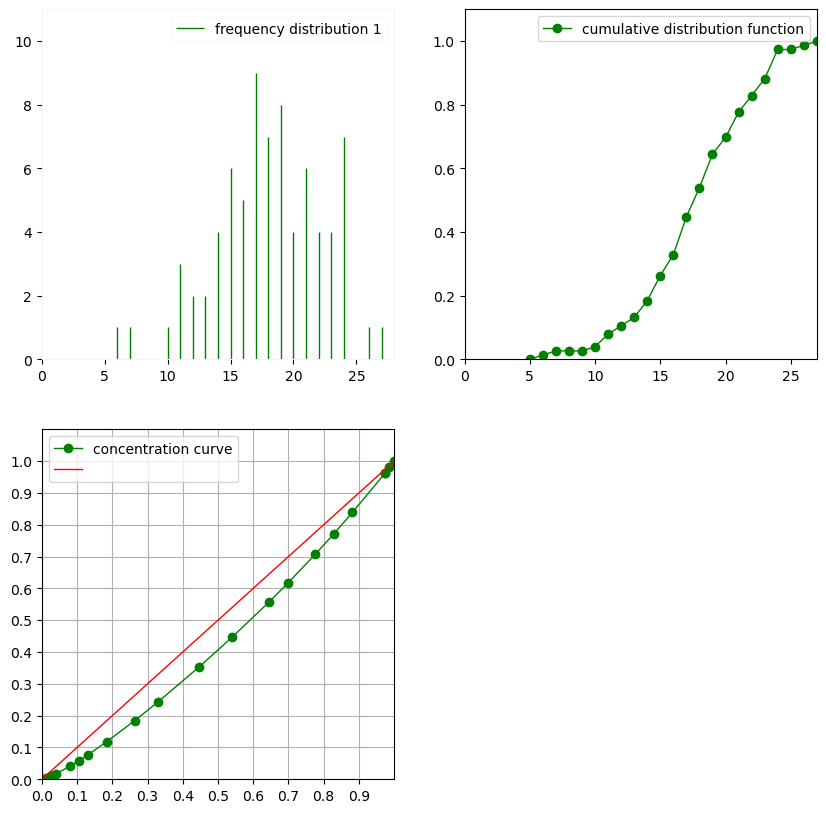

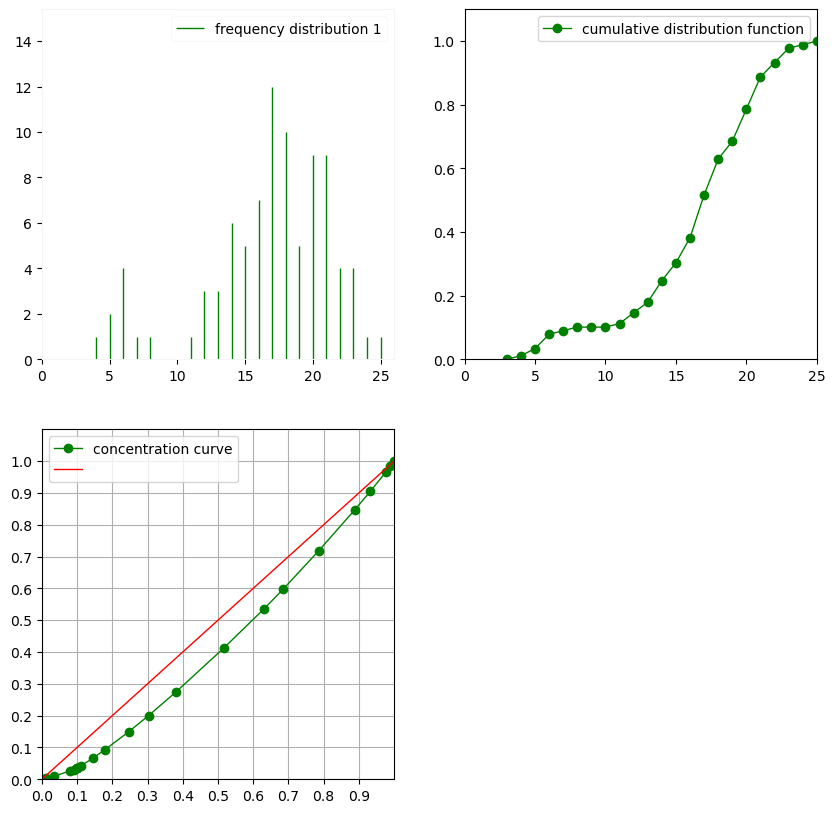

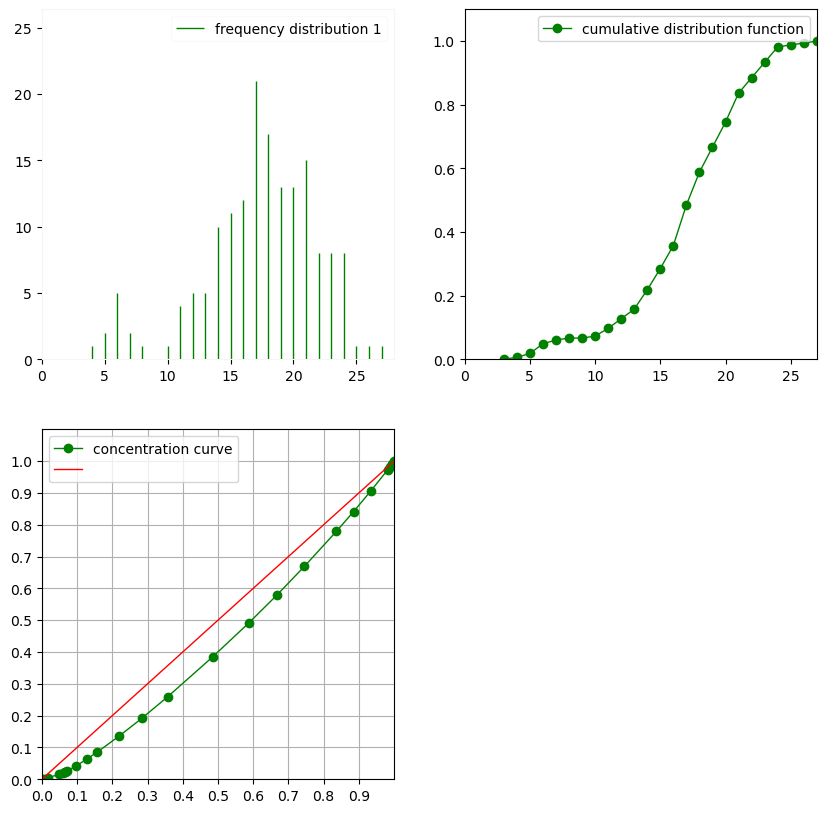

In [10]:
Plot(meri1)
Plot(meri2) 
Plot(meri12)

Arbitrary numbers of Histogram objects can be merged:

In [11]:
meri3 = Histogram(get_shared_data("meri3.his"))
meri123 = Merge(meri1, meri2, meri3)

This is equivalent to the method Histogram.merge:

In [12]:
meri123b = meri1.merge([meri2, meri3])
assert(str(meri123) == str(meri123b))